# Monte Carlo sampling of independent spins

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

In this notebook, we introduce the **Metropolis algorithm** on a very simple model: $N$ independent Ising spins in an external field. Because the spins do not interact with each other, we can compute all thermodynamic quantities analytically, and verify that the Monte Carlo simulation gives the correct results.

## The model

We consider $N$ spins $\sigma_i \in \{-1, +1\}$, subject to a uniform external field $h$. The energy of a configuration $\boldsymbol{\sigma} = (\sigma_1, \ldots, \sigma_N)$ is:

$$E(\boldsymbol{\sigma}) = -h \sum_{i=1}^{N} \sigma_i$$

Note that there is no interaction between spins (no $\sigma_i \sigma_j$ terms). Each spin simply prefers to align with the external field $h$.

At inverse temperature $\beta$, the Boltzmann distribution is:

$$P(\boldsymbol{\sigma}) = \frac{1}{Z} e^{-\beta E(\boldsymbol{\sigma})} = \frac{1}{Z} e^{\beta h \sum_i \sigma_i}$$

Since the spins are independent, this factorizes:

$$P(\boldsymbol{\sigma}) = \prod_{i=1}^{N} P(\sigma_i), \qquad P(\sigma_i) = \frac{e^{\beta h \sigma_i}}{2\cosh(\beta h)}$$

We can absorb $\beta$ into $h$ by redefining $h \to \beta h$, so in what follows $h$ plays the role of $\beta h$ (i.e., we set $\beta = 1$).

## Analytical results

Because the spins are independent, exact results are easy to derive.

The **average magnetization per spin** is:

$$m = \langle \sigma_i \rangle = \frac{e^{h} - e^{-h}}{e^{h} + e^{-h}} = \tanh(h)$$

The **variance** of a single spin is:

$$\text{Var}(\sigma_i) = 1 - \tanh^2(h) = \operatorname{sech}^2(h)$$

The **average energy per spin** is:

$$\frac{\langle E \rangle}{N} = -h \tanh(h)$$

These formulas let us verify that our Metropolis simulation works correctly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

## The Metropolis algorithm

The Metropolis algorithm generates samples from the Boltzmann distribution $P(\boldsymbol{\sigma}) \propto e^{-E(\boldsymbol{\sigma})}$ by performing local updates. At each step:

1. Pick a random spin $i$.
2. Compute the energy change $\Delta E$ that would result from flipping $\sigma_i \to -\sigma_i$.
3. Accept the flip with probability $\min(1, e^{-\Delta E})$.

For our model, flipping $\sigma_i \to -\sigma_i$ gives:

$$\Delta E = -h(-\sigma_i) - (-h \sigma_i) = 2h\sigma_i$$

so the flip is always accepted when $h \sigma_i < 0$ (the spin aligns with the field), and accepted with probability $e^{-2h\sigma_i}$ otherwise.

In [2]:
@njit
def metropolis_sweep(sigma, h, N, n_steps):
    """Perform n_steps Metropolis single-spin-flip updates (in-place).
    sigma: array of spins encoded as 0/1 (representing -1/+1).
    h: external field (absorbed beta*h).
    """
    for _ in range(n_steps):
        i = np.random.randint(0, N)
        s = 2 * sigma[i] - 1  # convert 0/1 to -1/+1
        dE = 2.0 * h * s
        if dE <= 0.0 or np.random.random() < np.exp(-dE):
            sigma[i] = 1 - sigma[i]


def metropolis(h, N, steps_between_frames, number_of_frames):
    """Run Metropolis simulation for N independent spins in external field h.
    Returns the magnetization per spin trace.
    """
    sigma = np.random.randint(0, 2, N, dtype=np.int8)
    mag = np.zeros(number_of_frames)
    mag[0] = (2.0 * np.sum(sigma) - N) / N
    for f in range(1, number_of_frames):
        metropolis_sweep(sigma, h, N, steps_between_frames)
        mag[f] = (2.0 * np.sum(sigma) - N) / N
    return mag

In [3]:
# Warm up numba JIT (first call triggers compilation)
_ = metropolis(0.5, 10, 100, 10)

## Magnetization trace

Let us first run the simulation for a few values of the external field $h$ and observe how the magnetization per spin evolves over time. We expect the system to quickly equilibrate to a value close to $\tanh(h)$.

In [4]:
N = 100  # number of spins
values_of_h = [0.0, 0.2, 0.5, 1.0]

traces = {}
for h in values_of_h:
    print(f"Simulating h={h}...")
    traces[h] = metropolis(h, N, steps_between_frames=N, number_of_frames=5000)
    print(f"  done.")

Simulating h=0.0...
  done.
Simulating h=0.2...
  done.
Simulating h=0.5...
  done.
Simulating h=1.0...
  done.


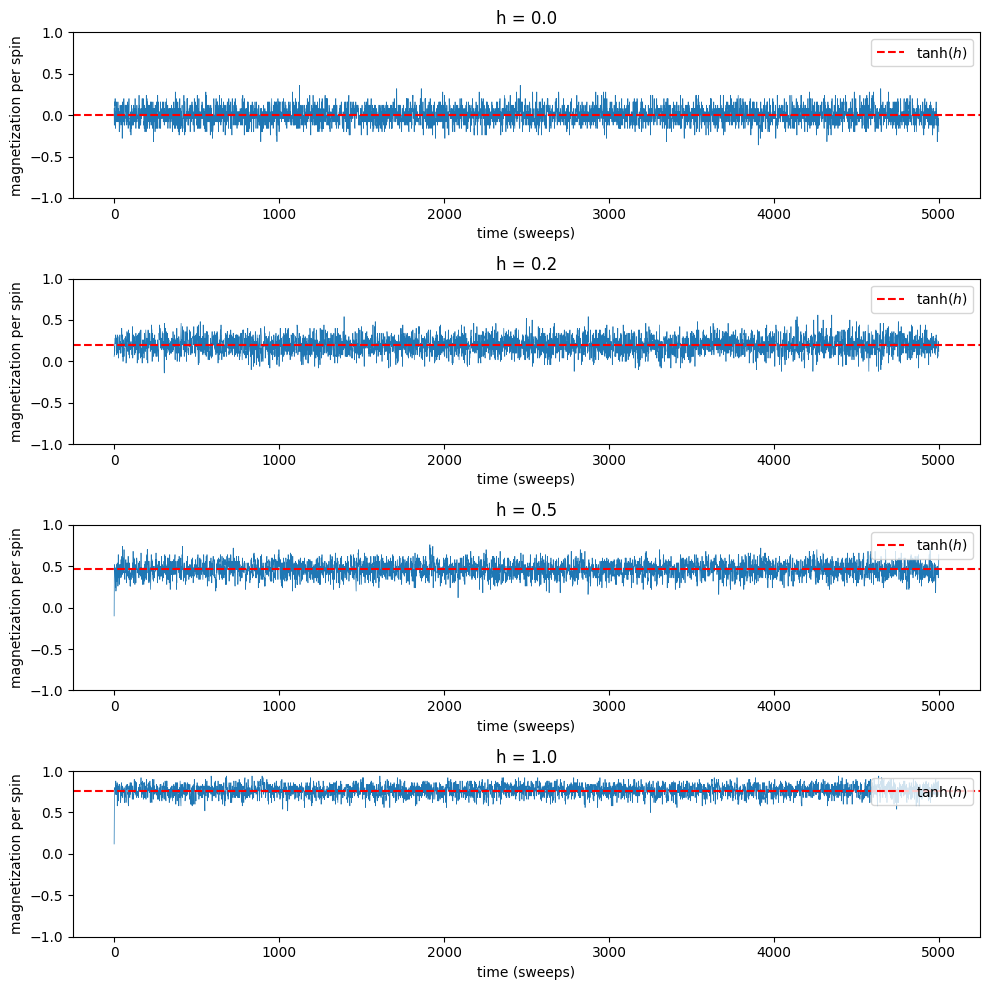

In [5]:
fig, axes = plt.subplots(len(values_of_h), 1, figsize=(10, 2.5 * len(values_of_h)))
for ax, h in zip(axes, values_of_h):
    ax.plot(traces[h], linewidth=0.5)
    ax.axhline(np.tanh(h), color="red", linestyle="--", linewidth=1.5, label=r"$\tanh(h)$")
    ax.set_title(f"h = {h}")
    ax.set_xlabel("time (sweeps)")
    ax.set_ylabel("magnetization per spin")
    ax.set_ylim(-1, 1)
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The magnetization fluctuates around the analytical value $\tanh(h)$ (red dashed line). For $h = 0$, the magnetization fluctuates symmetrically around zero. As $h$ increases, the spins prefer to align with the field, and the average magnetization increases towards $+1$.

## Average magnetization vs. external field

We now sweep over many values of $h$ and compare the Monte Carlo estimate of the average magnetization to the exact result $m = \tanh(h)$.

In [6]:
N = 100
values_of_h_sweep = np.linspace(-2, 2, 21)
n_warmup = 500  # discard initial transient

mc_mag_avg = []
mc_mag_std = []
for h in values_of_h_sweep:
    print(f"  h={h:.2f}...")
    mag = metropolis(h, N, steps_between_frames=N, number_of_frames=10_000)
    mc_mag_avg.append(np.mean(mag[n_warmup:]))
    mc_mag_std.append(np.std(mag[n_warmup:]))

mc_mag_avg = np.array(mc_mag_avg)
mc_mag_std = np.array(mc_mag_std)

  h=-2.00...
  h=-1.80...
  h=-1.60...
  h=-1.40...
  h=-1.20...
  h=-1.00...
  h=-0.80...
  h=-0.60...
  h=-0.40...
  h=-0.20...
  h=0.00...
  h=0.20...
  h=0.40...
  h=0.60...
  h=0.80...
  h=1.00...
  h=1.20...
  h=1.40...
  h=1.60...
  h=1.80...
  h=2.00...


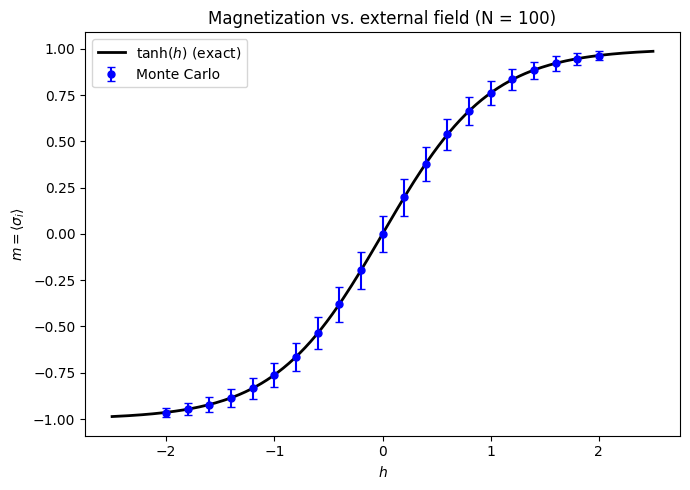

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
h_fine = np.linspace(-2.5, 2.5, 200)
ax.plot(h_fine, np.tanh(h_fine), "k-", linewidth=2, label=r"$\tanh(h)$ (exact)")
ax.errorbar(values_of_h_sweep, mc_mag_avg, yerr=mc_mag_std, fmt="o", markersize=5,
            color="blue", capsize=3, label="Monte Carlo")
ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$m = \langle \sigma_i \rangle$")
ax.legend()
ax.set_title(f"Magnetization vs. external field (N = {N})")
plt.tight_layout()
plt.show()

The Monte Carlo results agree with the exact $\tanh(h)$ curve. The error bars represent the standard deviation of the magnetization over the simulation, which reflects both thermal fluctuations and Monte Carlo noise.

## Distribution of the magnetization

Since the spins are independent, the total magnetization $M = \sum_i \sigma_i$ is a sum of i.i.d. random variables. By the central limit theorem, for large $N$, the magnetization per spin $m = M/N$ is approximately Gaussian:

$$m \approx \mathcal{N}\!\left(\tanh(h),\; \frac{\operatorname{sech}^2(h)}{N}\right)$$

Let us verify this by plotting histograms of the magnetization from our simulation.

In [14]:
N = 500
values_of_h_hist = [0.0, 0.3, 0.7, 1.5]

hist_traces = {}
for h in values_of_h_hist:
    print(f"Simulating h={h}...")
    hist_traces[h] = metropolis(h, N, steps_between_frames=N, number_of_frames=50_000)
    print(f"  done.")

Simulating h=0.0...
  done.
Simulating h=0.3...
  done.
Simulating h=0.7...
  done.
Simulating h=1.5...
  done.


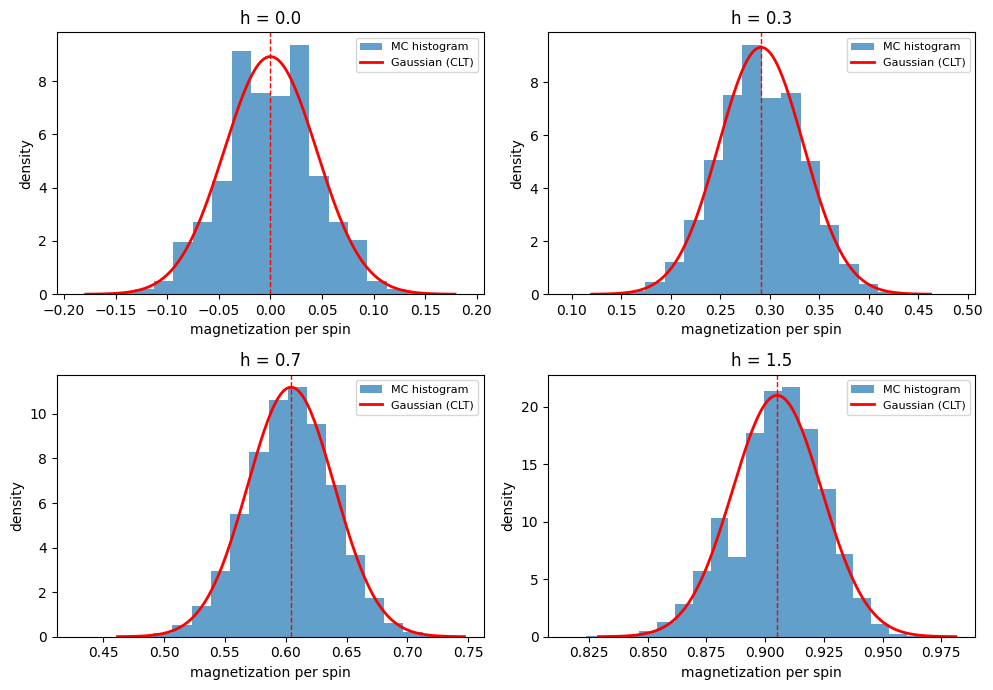

In [16]:
from scipy.stats import norm

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, h in zip(axes.flat, values_of_h_hist):
    data = hist_traces[h][500:]  # discard warmup
    ax.hist(data, bins=20, density=True, alpha=0.7, label="MC histogram")
    # Overlay the Gaussian prediction
    mu = np.tanh(h)
    sigma = np.sqrt(1.0 / (N * np.cosh(h)**2))
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax.plot(x, norm.pdf(x, mu, sigma), "r-", linewidth=2, label="Gaussian (CLT)")
    ax.axvline(mu, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"h = {h}")
    ax.set_xlabel("magnetization per spin")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The histograms match the Gaussian prediction from the central limit theorem. Note that as $|h|$ increases, the variance decreases (the spins are more firmly aligned with the field, so there are fewer fluctuations).

## Effect of system size

As the number of spins $N$ increases, the fluctuations of the magnetization per spin decrease as $1/\sqrt{N}$. Let us verify this.

In [10]:
h_fixed = 0.5
values_of_N = [10, 50, 200, 1000]

size_traces = {}
for N in values_of_N:
    print(f"Simulating N={N}...")
    size_traces[N] = metropolis(h_fixed, N, steps_between_frames=N, number_of_frames=20_000)
    print(f"  done.")

Simulating N=10...
  done.
Simulating N=50...
  done.
Simulating N=200...
  done.
Simulating N=1000...
  done.


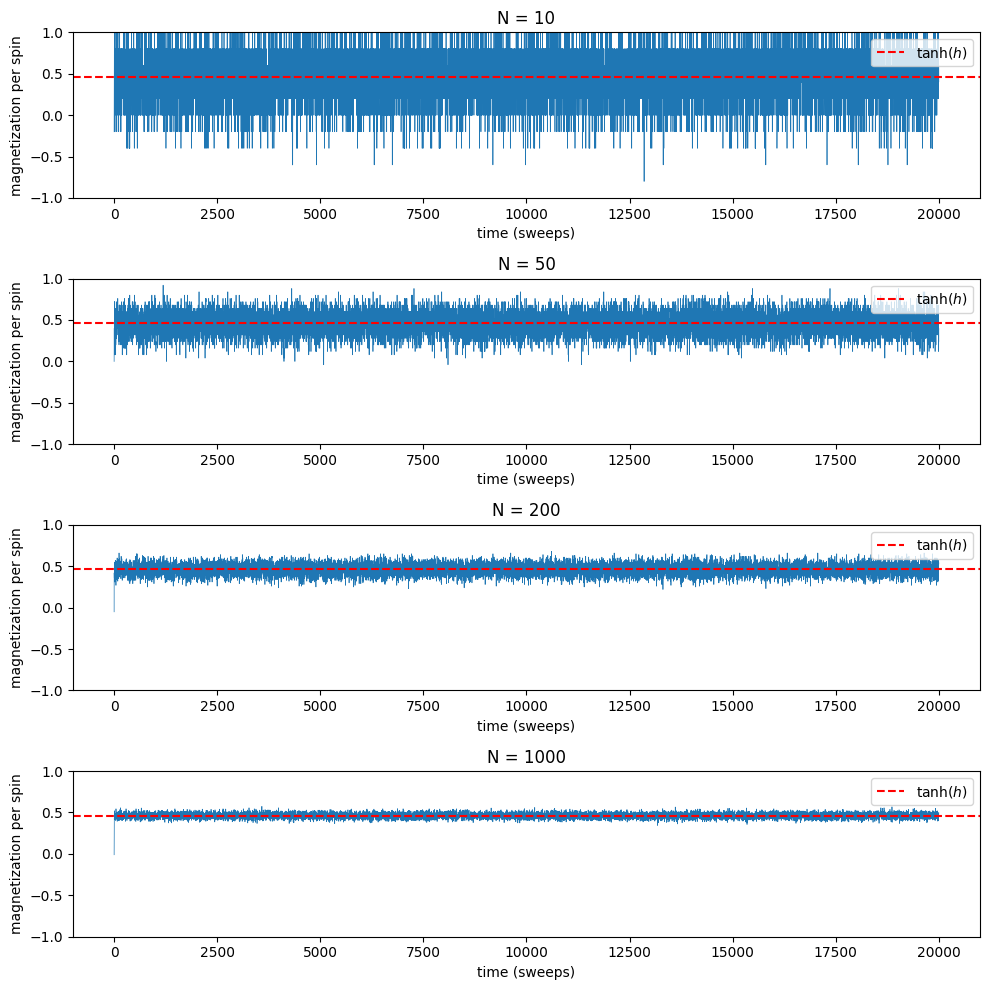

In [11]:
fig, axes = plt.subplots(len(values_of_N), 1, figsize=(10, 2.5 * len(values_of_N)))
for ax, N in zip(axes, values_of_N):
    ax.plot(size_traces[N], linewidth=0.5)
    ax.axhline(np.tanh(h_fixed), color="red", linestyle="--", linewidth=1.5, label=r"$\tanh(h)$")
    ax.set_title(f"N = {N}")
    ax.set_xlabel("time (sweeps)")
    ax.set_ylabel("magnetization per spin")
    ax.set_ylim(-1, 1)
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

As expected, the fluctuations decrease with increasing $N$. With $N = 1000$ spins, the magnetization per spin is very close to $\tanh(h)$ at all times.

## Summary

In this notebook, we implemented the Metropolis algorithm for the simplest possible Ising model: independent spins in an external field. We verified that:

1. The average magnetization per spin converges to the exact value $m = \tanh(h)$.
2. The distribution of the magnetization is Gaussian, as predicted by the central limit theorem.
3. Fluctuations decrease as $1/\sqrt{N}$ with increasing system size.

This simple example illustrates the basic mechanics of the Metropolis algorithm before applying it to more complex models with interactions (see the Ising model notebook).